# Exproratory Data Analysis
In this analysis, we deconstruct the price action of the pair eur/usd to understand its underlying market dynamics. Beyond simple price visualization, we investigate the statistical structure of returns across different timeframes. Our goal is to isolate the signal from the noise, identifying volatility clusters and seasonal patterns that drive market risk, laying the groundwork for predictive modeling.

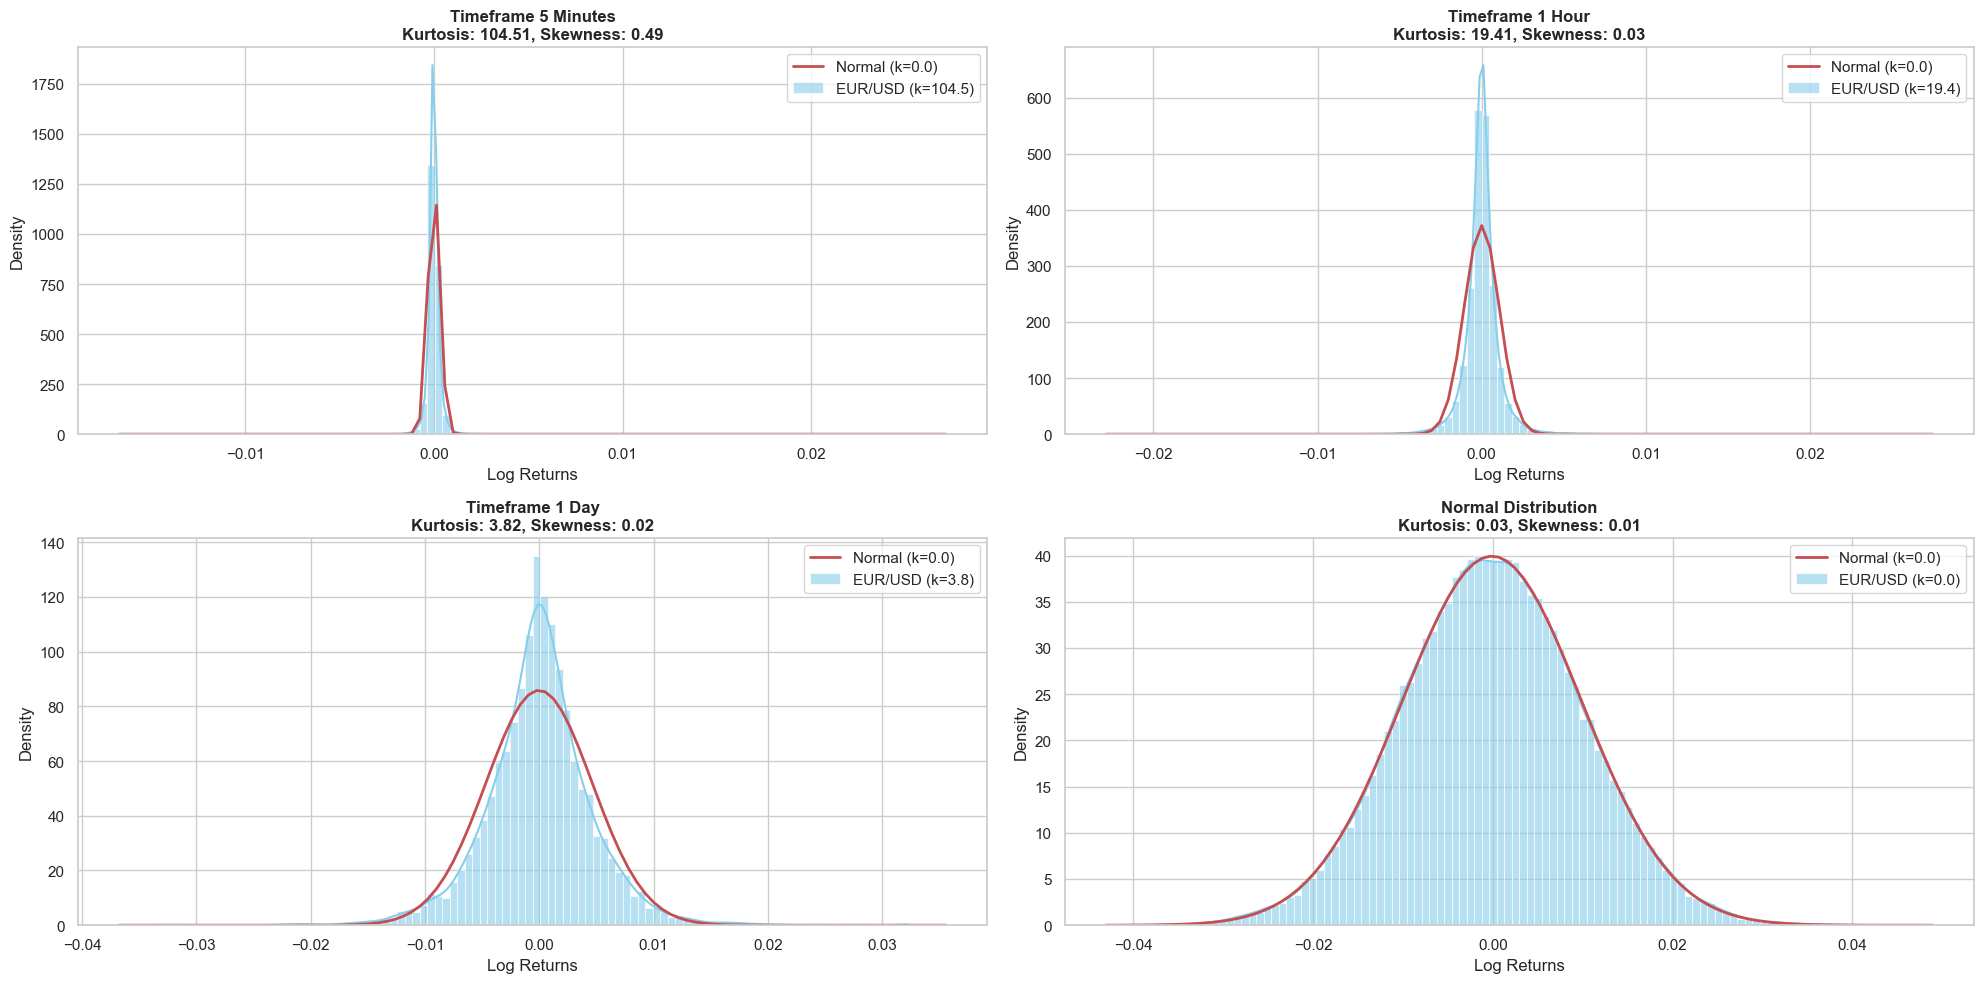

In [5]:
# configuration for multiple plots
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(20, 10))

# Generating normal distribution dataset
datos = np.random.normal(loc=0, scale=0.01, size=60000)
initial_price = 1
df_normal = initial_price * np.exp(np.cumsum(datos))
df_normal = pd.DataFrame(df_normal, columns=['Close'])
df_normal['log_return'] = np.log(df_normal['Close'] / df_normal['Close'].shift(1))
df_normal.dropna(inplace=True)

# List of datasets and their names
datasets = [
    (df_5m, "Timeframe 5 Minutes"),
    (df_1h, "Timeframe 1 Hour"),
    (df_1d, "Timeframe 1 Day"),
    (df_normal, "Normal Distribution")
]

# Loop through datasets and plot
for ax, (df, name) in zip(axes.flatten(), datasets):
    
    # Logaritmic Returns Calculation
    data = df.copy()
    
    # Kurtosis Calculation
    k_val = stats.kurtosis(data['log_return'], fisher=True)
    s_val = stats.skew(data['log_return'])
    
    # Logaritmic returns Histogram
    sns.histplot(data['log_return'], bins=100, kde=True, stat="density", 
                 color='skyblue', alpha=0.6, label=f"EUR/USD (k={k_val:.1f})", ax=ax)
    
    # Normal distribution line
    mu, std = stats.norm.fit(data['log_return'])
    xmin, xmax = ax.get_xlim()
    x = np.linspace(xmin, xmax, 100)
    p = stats.norm.pdf(x, mu, std)

    # Plot normal distribution
    ax.plot(x, p, 'r', linewidth=2, label="Normal (k=0.0)")
    ax.set_title(f'{name}\nKurtosis: {k_val:.2f}, Skewness: {s_val:.2f}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Log Returns')
    ax.set_ylabel('Density')
    ax.legend()
plt.tight_layout()
plt.show()

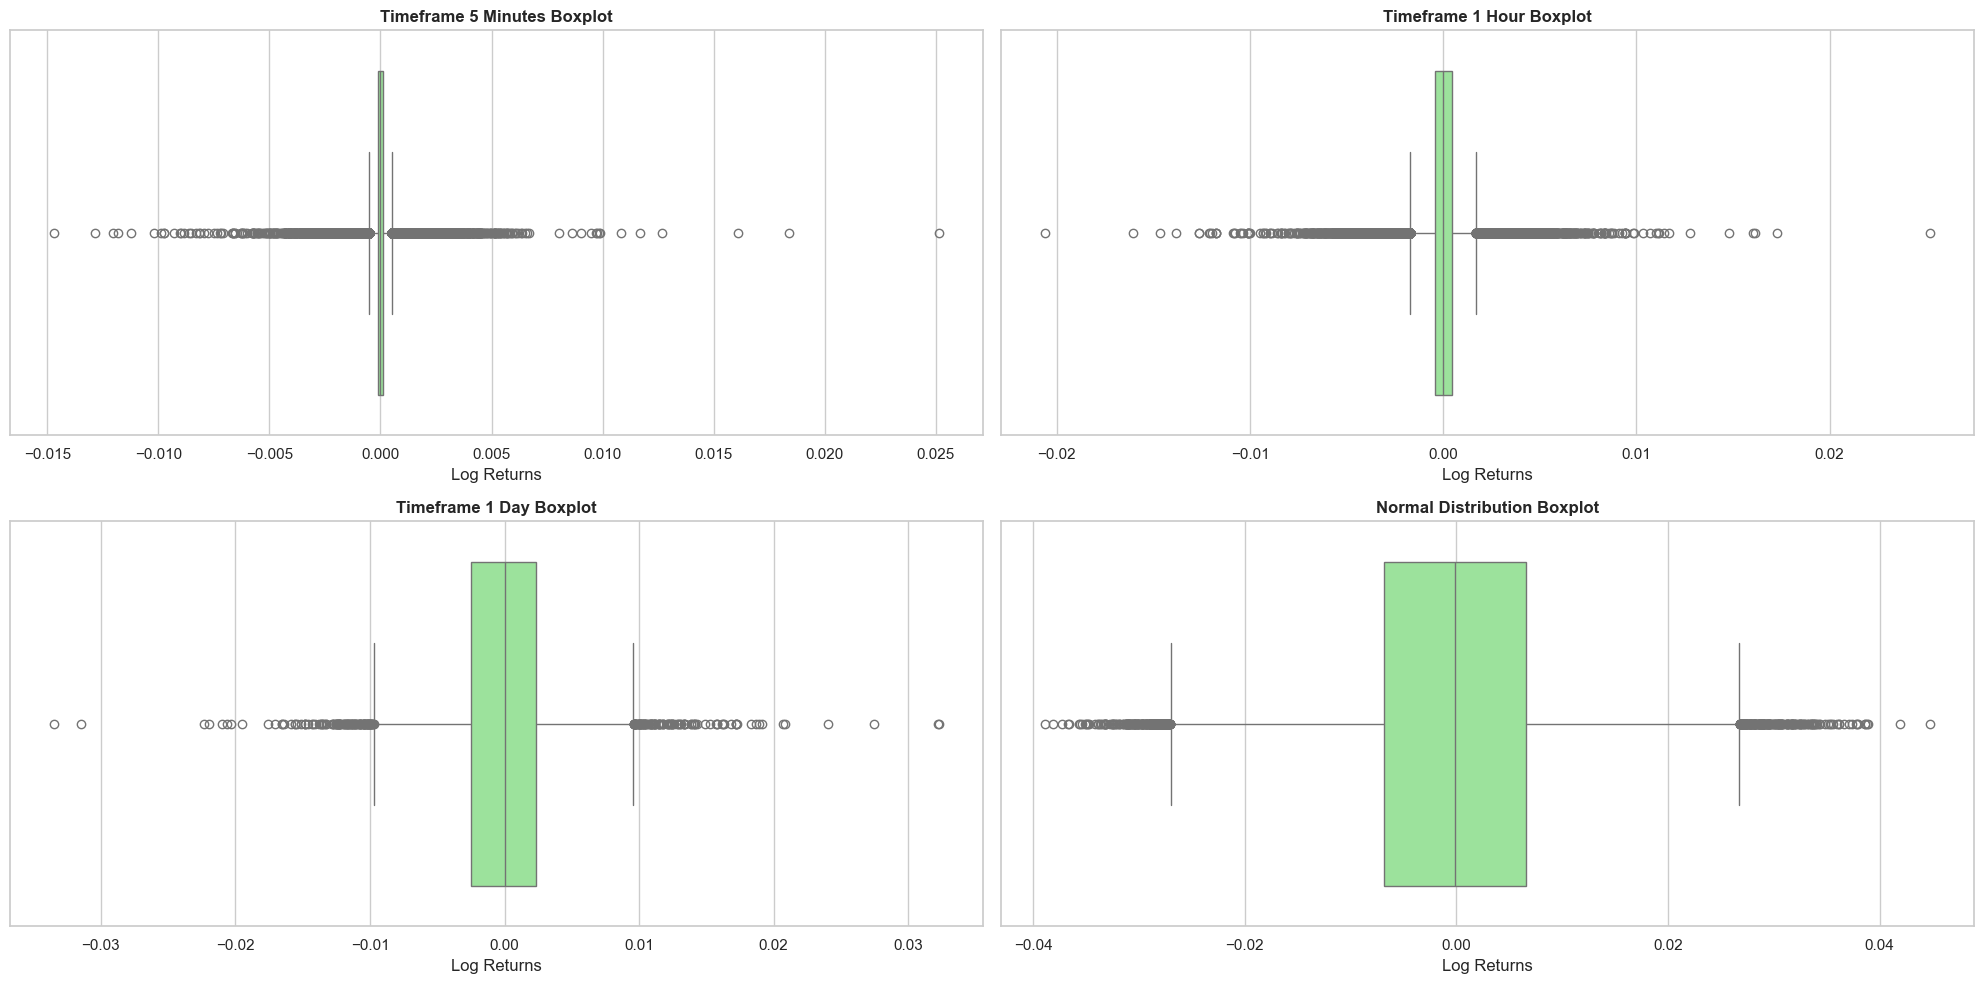

In [8]:
# Boxplot comparison

fig, axes = plt.subplots(2, 2, figsize=(20, 10))

# List of datasets and their names
datasets = [
    (df_5m, "Timeframe 5 Minutes"),
    (df_1h, "Timeframe 1 Hour"),
    (df_1d, "Timeframe 1 Day"),
    (df_normal, "Normal Distribution")
]

# Loop through datasets and plot
for ax, (df, name) in zip(axes.flatten(), datasets):
    # Copy of dataset
    data = df.copy()

    # boxplot calculation
    sns.boxplot(x=data['log_return'], ax=ax, color='lightgreen')
    ax.set_title(f'{name} Boxplot', fontsize=12, fontweight='bold')
    ax.set_xlabel('Log Returns')
plt.tight_layout()
plt.show()  

In [ ]:
# Counting outliers in each dataset
def counting_outliers(df, name):
    data = df.copy()
    Q1 = data['log_return'].quantile(0.25)
    Q3 = data['log_return'].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    negative_outliers = data[(data['log_return'] < lower_bound)]
    positive_outliers = data[(data['log_return'] > upper_bound)]

    # Calculating outlier statistics
    num_outliers = len(negative_outliers) + len(positive_outliers)
    total_points = len(data)
    percentage = (num_outliers / total_points) * 100
    min_outlier = np.exp(negative_outliers['log_return'].min()) - 1 
    date_min_outlier = data[data['log_return'] == np.log(min_outlier + 1)].index[0]
    max_outlier = np.exp(positive_outliers['log_return'].max()) - 1 
    date_max_outlier = data[data['log_return'] == np.log(max_outlier + 1)].index[0]
    percentage_positive_outliers = (len(positive_outliers) / num_outliers) * 100

    # Printing the results
    print(f"OUTLIERS RESULTS OF {name}")
    print(f"№ The number of outliers is: {num_outliers}.")
    print(f"📊 The percentage of outliers is: {percentage:.2f}%.")
    print(f"➡️ The percentage of positive outliers is: {percentage_positive_outliers:.2f}%.")
    print(f"➡️ The percentage of negative outliers is: {100 - percentage_positive_outliers:.2f}%.")
    print(f"📈 The highest value is: {max_outlier*100:.2f}%, in the {date_max_outlier}.")
    print(f"📉 The lowest value is: {min_outlier*100:.2f}%, in the {date_min_outlier}.")
    print('-'*50)

counting_outliers(df_5m, "Timeframe 5 Minutes")
counting_outliers(df_1h, "Timeframe 1 Hour")
counting_outliers(df_1d, "Timeframe 1 Day")
counting_outliers(df_normal, "Normal Distribution")


OUTLIERS RESULTS OF Timeframe 5 Minutes
№ The number of outliers is: 84532.
📊 The percentage of outliers is: 7.69%.
➡️ The percentage of positive outliers is: 49.57%.
➡️ The percentage of negative outliers is: 50.43%.
📈 The highest value is: 2.55%, in the 2025-09-01 00:00:00.
📉 The lowest value is: -1.46%, in the 2015-06-28 17:00:00.
Last year's lowest value: -0.10%
--------------------------------------------------
OUTLIERS RESULTS OF Timeframe 1 Hour
№ The number of outliers is: 7411.
📊 The percentage of outliers is: 8.09%.
➡️ The percentage of positive outliers is: 50.01%.
➡️ The percentage of negative outliers is: 49.99%.
📈 The highest value is: 2.55%, in the 2025-09-01 00:00:00.
📉 The lowest value is: -2.04%, in the 2016-06-23 22:00:00.
Last year's lowest value: -0.46%
--------------------------------------------------
OUTLIERS RESULTS OF Timeframe 1 Day
№ The number of outliers is: 220.
📊 The percentage of outliers is: 4.75%.
➡️ The percentage of positive outliers is: 49.09%.
➡️ 

we are taking a deeper look on the extreme outliers.

In [35]:
# Extreme values
def counting_outliers(df, name):
    data = df.copy()
    Q1 = data['log_return'].quantile(0.25)
    Q3 = data['log_return'].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    negative_outliers = data[(data['log_return'] < lower_bound)].sort_values(by='log_return')
    positive_outliers = data[(data['log_return'] > upper_bound)].sort_values(by='log_return', ascending=False)

    print(f"EXTREME NEGATIVE OUTLIERS OF {name}")
    print(negative_outliers['log_return'].head(10))
    print(f"EXTREME POSITIVE OUTLIERS OF {name}")
    print(positive_outliers['log_return'].head(10))

counting_outliers(df_5m, "Timeframe 5 Minutes")
counting_outliers(df_1h, "Timeframe 1 Hour")
counting_outliers(df_1d, "Timeframe 1 Day")
counting_outliers(df_normal, "Normal Distribution")


EXTREME NEGATIVE OUTLIERS OF Timeframe 5 Minutes
timestamp
2015-06-28 17:00:00   -0.014687
2013-03-17 17:00:00   -0.012831
2022-02-27 17:00:00   -0.012049
2015-07-05 17:00:00   -0.011813
2025-02-02 17:00:00   -0.011233
2015-03-18 16:05:00   -0.010207
2013-11-07 07:45:00   -0.009885
2022-10-13 08:30:00   -0.009764
2015-11-06 08:30:00   -0.009740
2022-09-25 20:55:00   -0.009299
Name: log_return, dtype: float64
EXTREME POSITIVE OUTLIERS OF Timeframe 5 Minutes
timestamp
2025-09-01 00:00:00    0.025135
2015-03-18 16:00:00    0.018377
2017-04-23 17:00:00    0.016095
2022-11-10 08:30:00    0.012694
2015-12-03 08:30:00    0.011706
2011-11-30 08:00:00    0.010845
2016-03-10 09:10:00    0.009891
2015-10-02 08:30:00    0.009839
2011-08-07 17:00:00    0.009755
2015-04-03 08:30:00    0.009690
Name: log_return, dtype: float64
EXTREME NEGATIVE OUTLIERS OF Timeframe 1 Hour
timestamp
2016-06-23 22:00:00   -0.020606
2015-06-28 17:00:00   -0.016088
2015-10-28 14:00:00   -0.014644
2022-09-13 08:00:00   -0

there is a big difference between a noraml outlier and the max or min outlier

In [ ]:
# Heterocedasticity Test
datasets = [(df_5m, "Timeframe 5 Minutes"), (df_1h, "Timeframe 1 Hour"), (df_1d, "Timeframe 1 Day"), (df_normal, "Normal Distribution")]   
for df, name in datasets:
    data = df.copy()
    

NameError: name 'sm' is not defined